# Object Detection
Is the two-step process for detecting a specified image/figure and then classify each detected image.
They generate several predictions from a single image.\
The foundational acrchitecture is called *U-NET* which is the facto design approach for image segmentation.
## Image Segmentation
It is a classification problem that classifies *every pixel*. A 200 x 200 image will have 40,000 classifications.
### Nuclei detection: Loading the data
Example using the 2018 Data Science Bowl. 

In [2]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

 dl_utils loaded
Device available: cuda


/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Representing the image segmentation problem in PyTorch
Use the data to visulize some images

In [6]:
# Visualize the data
from glob import glob

paths = sorted(glob("./data/DSB/stage1_train/*/"))
print(f"✅ Found {len(paths)} samples.") 

✅ Found 670 samples.


In [9]:
dsb_data = DSB2018_EZA(paths)
print(f"Dataset length : {len(dsb_data)}")

img, mask = dsb_data[0]
print(f"Image shape    : {img.shape}")    # → torch.Size([3, 256, 256])
print(f"Mask shape     : {mask.shape}")   # → torch.Size([1, 256, 256])
print(f"Image range    : [{img.min():.3f}, {img.max():.3f}]")    # → [0.0, 1.0]
print(f"Mask unique    : {mask.unique()}")  # → tensor([0., 1.])  ← must be binary!


Dataset length : 670
Image shape    : torch.Size([3, 256, 256])
Mask shape     : torch.Size([1, 256, 256])
Image range    : [0.004, 0.424]
Mask unique    : tensor([0., 1.])


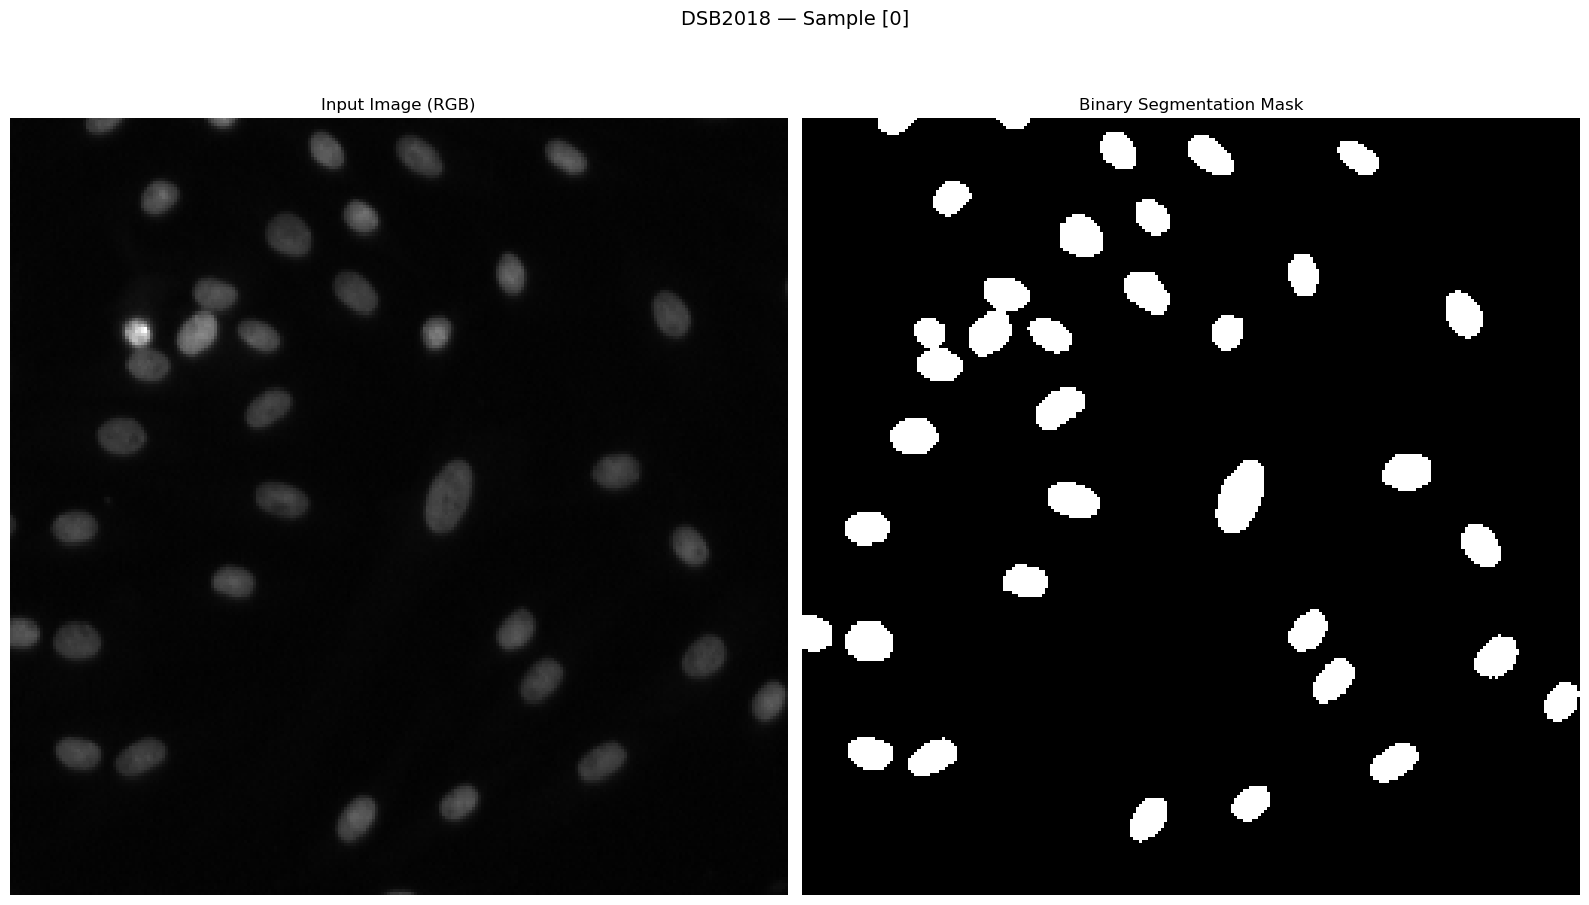

In [ ]:
# Better code to visualize the data
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(dsb_data[1][0].permute(1, 2, 0).numpy())  # CHW → HWC for matplotlib
axes[0].set_title("Input Image (RGB)")
axes[0].axis("off")

axes[1].imshow(dsb_data[1][1].numpy()[0, :], cmap="gray")  # (1,H,W) → (H,W)
axes[1].set_title("Binary Segmentation Mask")
axes[1].axis("off")

plt.suptitle("DSB2018 — Sample [0]", fontsize=14)
plt.tight_layout()
plt.show()

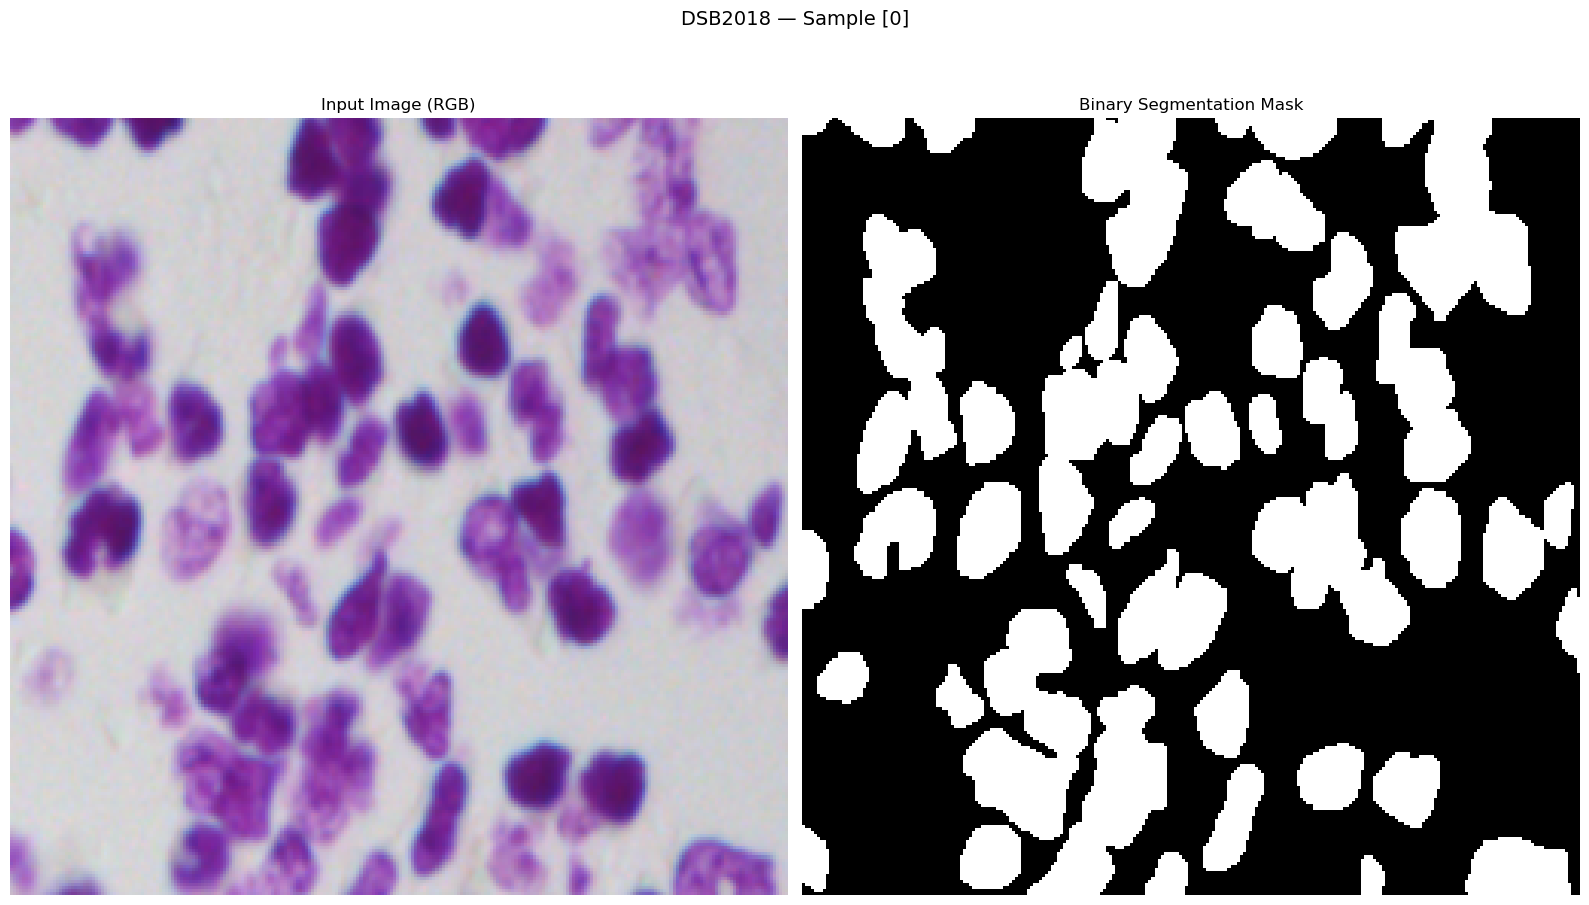

In [14]:
# Better code to visualize the data
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(dsb_data[2][0].permute(1, 2, 0).numpy())  # CHW → HWC for matplotlib
axes[0].set_title("Input Image (RGB)")
axes[0].axis("off")

axes[1].imshow(dsb_data[2][1].numpy()[0, :], cmap="gray")  # (1,H,W) → (H,W)
axes[1].set_title("Binary Segmentation Mask")
axes[1].axis("off")

plt.suptitle("DSB2018 — Sample [0]", fontsize=14)
plt.tight_layout()
plt.show()